In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(style='whitegrid',font_scale=2)
import os
os.chdir('/Users/daniel.garger/Desktop/Projects/C-PATH')
import scipy.cluster.hierarchy as sch

In [13]:
dir='TTP prediction'
pc = pd.read_csv(dir+'/data/ttp_pc.csv', low_memory=False)

#change number to 0  in PCTPTNUM column of pre-dose measurements to for all studies
pc.loc[pc[pc['PCTPT']=='PRE-DOSE'].index,'PCTPTNUM']=0

#get studies
studies=set(pc['STUDYID'].values)

#Standardize used drugs/metabolite names
pc['PCTEST']=pc['PCTEST'].str.replace(r'\bTMC207\b','Bedaquiline')
pc['PCTEST']=pc['PCTEST'].str.replace(r'\bPa-824\b','Pretomanid')
pc['PCTEST']=pc['PCTEST'].str.replace(r'\bR405786\b','N-Monodesmethyl Bedaquiline')
pc['PCTEST']=pc['PCTEST'].str.replace('Bedaquiline Metabolite M2','N-Monodesmethyl Bedaquiline')

/var/folders/0_/_m74rlq93855zphvhkg3qkhh19_hwl/T/ipykernel_79910/3382096095.py:11: FutureWarning: The default value of regex will change from True to False in a future version.
  pc['PCTEST']=pc['PCTEST'].str.replace(r'\bTMC207\b','Bedaquiline')
/var/folders/0_/_m74rlq93855zphvhkg3qkhh19_hwl/T/ipykernel_79910/3382096095.py:12: FutureWarning: The default value of regex will change from True to False in a future version.
  pc['PCTEST']=pc['PCTEST'].str.replace(r'\bPa-824\b','Pretomanid')
/var/folders/0_/_m74rlq93855zphvhkg3qkhh19_hwl/T/ipykernel_79910/3382096095.py:13: FutureWarning: The default value of regex will change from True to False in a future version.
  pc['PCTEST']=pc['PCTEST'].str.replace(r'\bR405786\b','N-Monodesmethyl Bedaquiline')




--------------------------------------------
1. Get time measurement temporal information from dataframe where 'PCDY' and 'PCTPTNUM' column doesn't contain this information
2. Drop patient data where no temporal information or early withdrawal

In [14]:
########################################################################################
####------------------------------TB-1015-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1015']

#add hour of measurement information to PCTPTNUM column as floats
d=df[df['PCTPT'].str.contains('H',na=False)]
pc.loc[d.index,'PCTPTNUM']=d['PCTPT'].str.split('H',expand=True)[0].astype(float)

#add 0 hour to PCTPTNUM where only one measurement was conducted that day (last day of follow-up)
d=df[df['PCTPT'].isna()]
pc.loc[d.index,'PCTPTNUM']=0

#add day of measurement information to PCDY column as floats
d=df[df['PCDY'].isna()]
pc.loc[d.index,'PCDY']=d['PCTPTREF'].str.split('DAY | DOSE',expand=True)[1].astype(float)
d=df[df['PCDY'].isna()]
pc.loc[d.index,'PCDY']=d['VISIT'].str.split('DAY ',expand=True)[1].astype(float)

#drop UNSCHEDULED data, as time of measurement is missing
d=df[df['VISIT']=='UNSCHEDULED']
pc=pc.drop(index=d.index)

#drop all measurements of patients, who withdrew early from the study
d=df[df['VISIT'].str.contains('EARLY WITHDRAWAL')]
drop_pat=d['USUBJID'].unique().tolist()
pc=pc[~(pc['USUBJID'].isin(drop_pat))]

#correct incorrect registered day of measurement info of patient
df=pc[pc['USUBJID']=='TB-1015/20022']
pc.loc[df.index,'PCDY']=df['VISIT'].str.split('DAY ',expand=True)[1].astype(float)


########################################################################################
####------------------------------TB-1005-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1005']

#drop all measurements of patients, who withdrew early from the study
d=df[df['VISIT'].str.contains('EARLY WITHDRAWAL')]
drop_pat=d['USUBJID'].unique().tolist()
pc=pc[~(pc['USUBJID'].isin(drop_pat))]

df=pc[pc['STUDYID']=='TB-1005']
#add 0 hour to PCTPTNUM where only one measurement was conducted that day (last day of follow-up)
d=df[df['PCTPTNUM'].isna()]
pc.loc[d.index,'PCTPTNUM']=0

#correct typo in data (negative -21 day was registered)
pc.loc[pc[(pc['USUBJID']=='TB-1005/1049')&(pc['PCDY']==-21.0)].index,'PCDY']=10

########################################################################################
####------------------------------TB-1014-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1014']
#drop rows with no temporal information
pc=pc.drop(index=df[df['PCDY'].isna()].index)

#drop all measurements of patients, who withdrew early from the study
d=df[df['VISIT'].str.contains('EARLY WITHDRAWAL')]
drop_pat=d['USUBJID'].unique().tolist()
pc=pc[~(pc['USUBJID'].isin(drop_pat))]

df=pc[pc['STUDYID']=='TB-1014']
#add 0 hour to PCTPTNUM where only one measurement was conducted that day (last day of follow-up)
d=df[df['PCTPTNUM'].isna()]
pc.loc[d.index,'PCTPTNUM']=0

########################################################################################
####------------------------------TB-1011-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1011']

#drop all measurements of patients, who withdrew early from the study
d=df[df['VISIT'].str.contains('EARLY WITHDRAWAL')]
drop_pat=d['USUBJID'].unique().tolist()
pc=pc[~(pc['USUBJID'].isin(drop_pat))]

########################################################################################
####------------------------------TB-1018-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1018']

#add hour of measurement information to PCTPTNUM column as floats
d=df[df['PCTPT'].str.contains('H',na=False)]
pc.loc[d.index,'PCTPTNUM']=d['PCTPT'].str.split('H',expand=True)[0].astype(float)

#add hour of measurement information to PCDY column as floats where it is missing
df=pc[pc['STUDYID']=='TB-1018']
d=df[df['PCDY'].isna()]
pc.loc[d.index,'PCDY']=d['VISIT'].str.split('WEEK ',expand=True)[1].astype(float)




########################################################################################
####------------------------------TB-1008-------------------------------------------####
########################################################################################
df=pc[pc['STUDYID']=='TB-1008']

#drop all measurements of patients, who withdrew early from the study
d=df[df['VISIT'].str.contains('EARLY WITHDRAWAL')]
drop_pat=d['USUBJID'].unique().tolist()
pc=pc[~(pc['USUBJID'].isin(drop_pat))]


##### Calculate hour of measurement from the temporal information in the dataframe
##### Hour 0: first day of study, before the first application of drug


In [15]:
#   PCTPTNUM columns contains "Hours after dose' information
pc=pc.drop_duplicates()
#if PCTPTNUM< 24, just add (day-1)*24+Hours after dose
ind=pc[pc['PCTPTNUM']<24].index
pc.loc[ind,'hour']=(pc.loc[ind,'PCDY']-1)*24+pc.loc[ind,'PCTPTNUM']

# get correct time informaton if 24<=PCTPTNUM<=30 (extra day gets added in the PCDY column->have to correct for that)
ind=pc[(pc['PCTPTNUM']>=24)&(pc['PCTPTNUM']<=30)].index
pc.loc[ind,'hour']=(pc.loc[ind,'PCDY']-1)*24+pc.loc[ind,'PCTPTNUM']-24

# Some studies have measurements 2 weeks or 4 weeks after therapy, disregard information in PCTPTNUM column as it is not accurate,
# only consider accurate day information (day-1)*24
ind=pc[pc['PCTPTNUM']>30].index
pc.loc[ind,'hour']=(pc.loc[ind,'PCDY']-1)*24

##### Drop duplicated measurements

In [16]:
df=pc[pc['STUDYID']=='TB-1018']
for id in df['USUBJID'].unique():
    d=df[df['USUBJID']==id]
    for dr in d['PCTEST'].unique():
        dd=d[d['PCTEST']==dr]
        if dd.duplicated(subset=['hour']).any():
            pc=pc.drop(index=dd[dd.duplicated(subset=['hour'])].index)

for id in pc['USUBJID'].unique():
    df=pc[pc['USUBJID']==id]
    for dr in df['PCTEST'].unique():
        d=df[df['PCTEST']==dr]
        if d.duplicated(subset=['hour']).any():
            d=d.sort_values(by='VISITNUM',ascending=False)
            pc=pc.drop(index=d[d.duplicated(subset=['hour'])].index)

##### Impute concentration measurements where concentration of drug is under the lower detection limit:
###### - where applicable, replace NaN value of drug CC with the mean of the range under the lower detection limit
##### e.g. lower detection limit is 10 ng/mL -> replace NaN value with 5 ng/mL

In [17]:
d=pc[pc['PCSTRESN'].isna()]
d2=d[d['PCSTRESC'].str.contains('<')]
d2=d2['PCSTRESC'].str.split('<',expand=True)[1].astype(float)/2
pc.loc[d2.index,'PCSTRESN']=d2.values.tolist()

d3=d[(~d['PCSTRESC'].str.contains('<'))&(~d['PCLLOQ'].isna())&(~d['COMMENT'].str.contains('Insufficient',na=False))]
pc.loc[d3.index,'PCSTRESN']=d3['PCLLOQ']/2


##### Standardise measurements units to mg/L and convert if necessary

In [18]:
pc['STD_NUM_RESULT']=pc['PCSTRESN']
pc['STD_UNITS']=pc['PCSTRESU']

a=pc[pc['PCSTRESU']=='ng/mL']
pc.loc[a.index,'STD_NUM_RESULT']=a['PCSTRESN']
pc.loc[a.index,'STD_UNITS']='ug/L'


b=pc[pc['PCSTRESU']=='mg/L']
pc.loc[b.index,'STD_NUM_RESULT']=b['PCSTRESN']/1000
pc.loc[b.index,'STD_UNITS']='ug/L'

-----------------------------------------------------------
#### Subset pharmacokinetic measurement points that only contain CONCENTRATION PEAKS
-----------------------------------------------------------

In [9]:
pc_peaks=pd.DataFrame()
for study in list(studies)[:]:
    df=pc[pc['STUDYID']==study]
    d=df[(df['PCTPTNUM']>0)&(df['PCTPTNUM']<31)]
    days=sorted(d['PCDY'].unique())
    d=df[df['PCDY'].isin(days)]
    pc_peaks=pc_peaks.append(d)
pc_peaks.to_csv(dir+'/data/ttp_pc_peaks.csv',index=None)

-----------------------------------------------------------
#### Subset pharmacokinetic measurement points that only contain BASELINE(=PRE DOSE) VALUES
-----------------------------------------------------------

In [19]:
pc_baseline=pd.DataFrame()
for study in list(studies)[:]:
    df=pc[pc['STUDYID']==study]
    d=df[(df['PCTPTNUM']==0)|(df['PCTPTNUM']>31)]
    pc_baseline=pc_baseline.append(d)

pc_baseline.to_csv(dir+'/data/ttp_pc_baseline.csv',index=None)

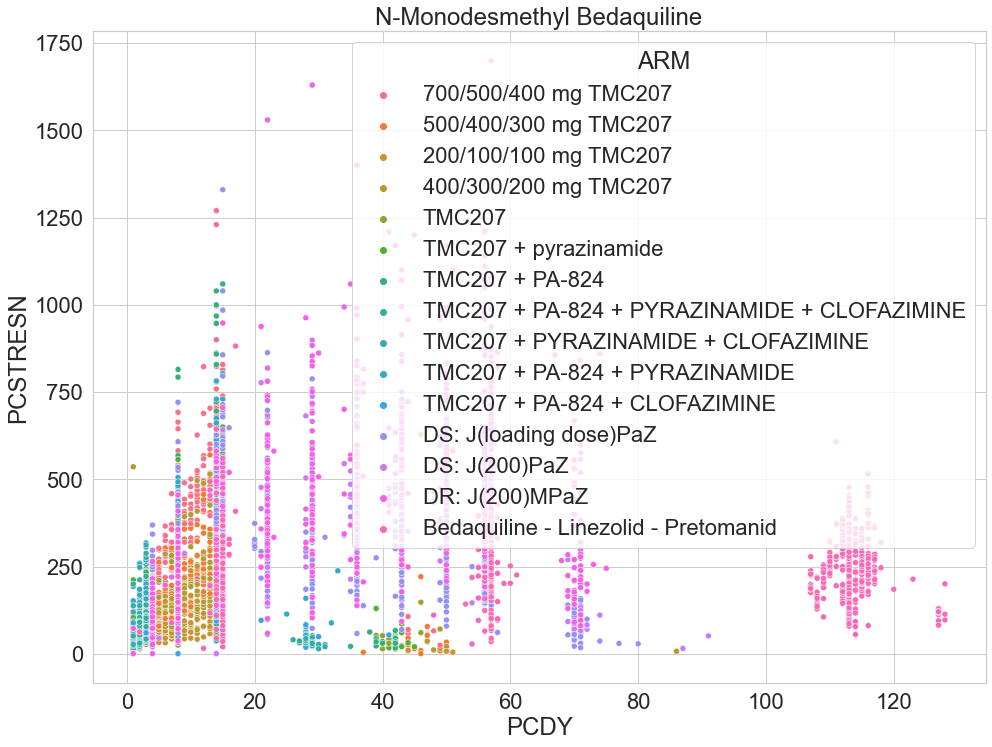

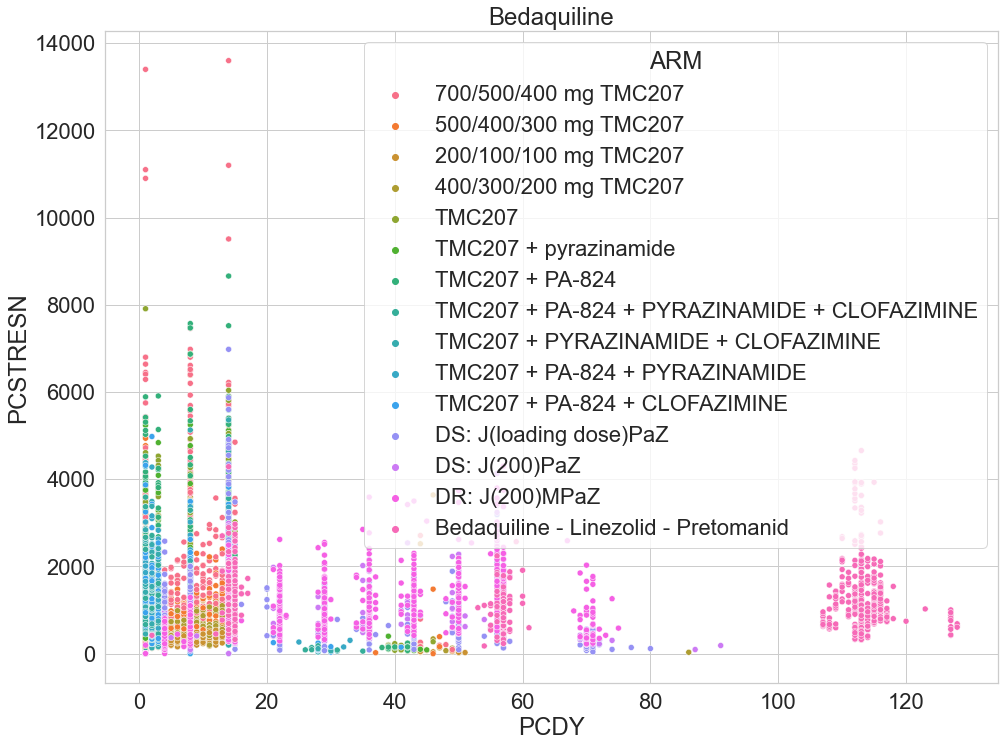

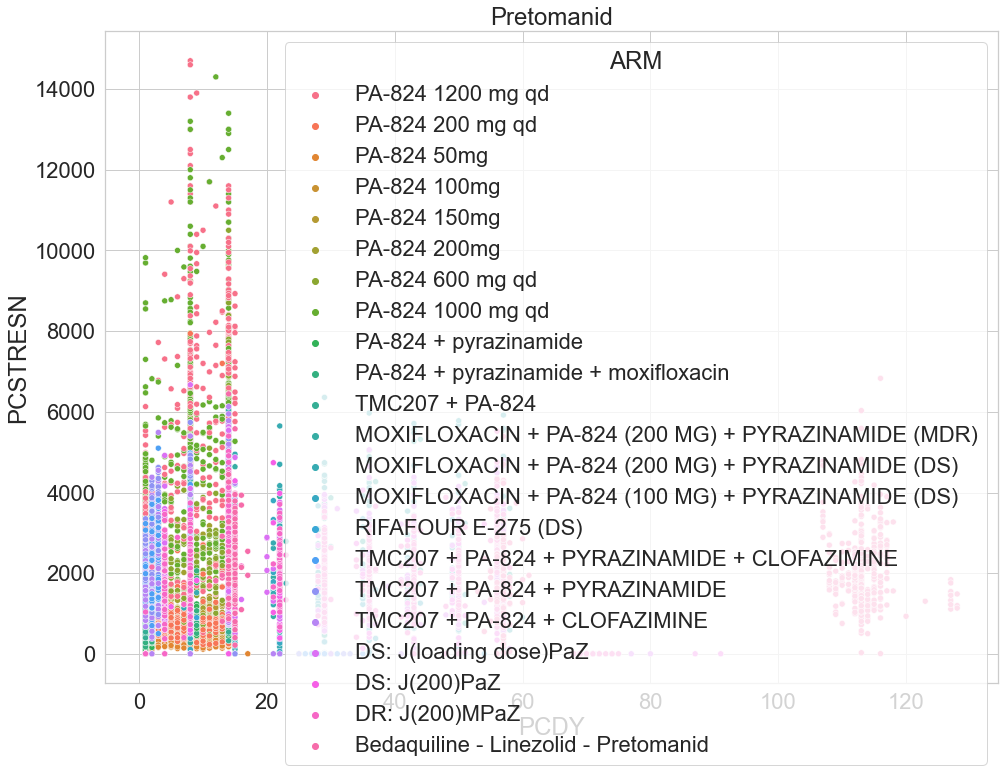

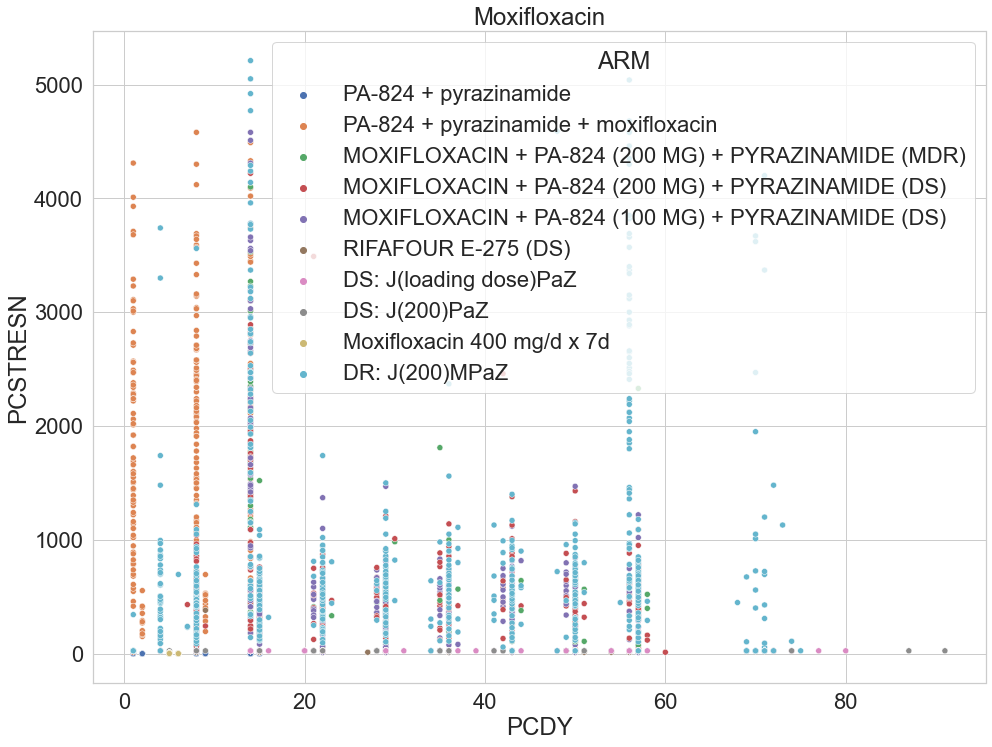

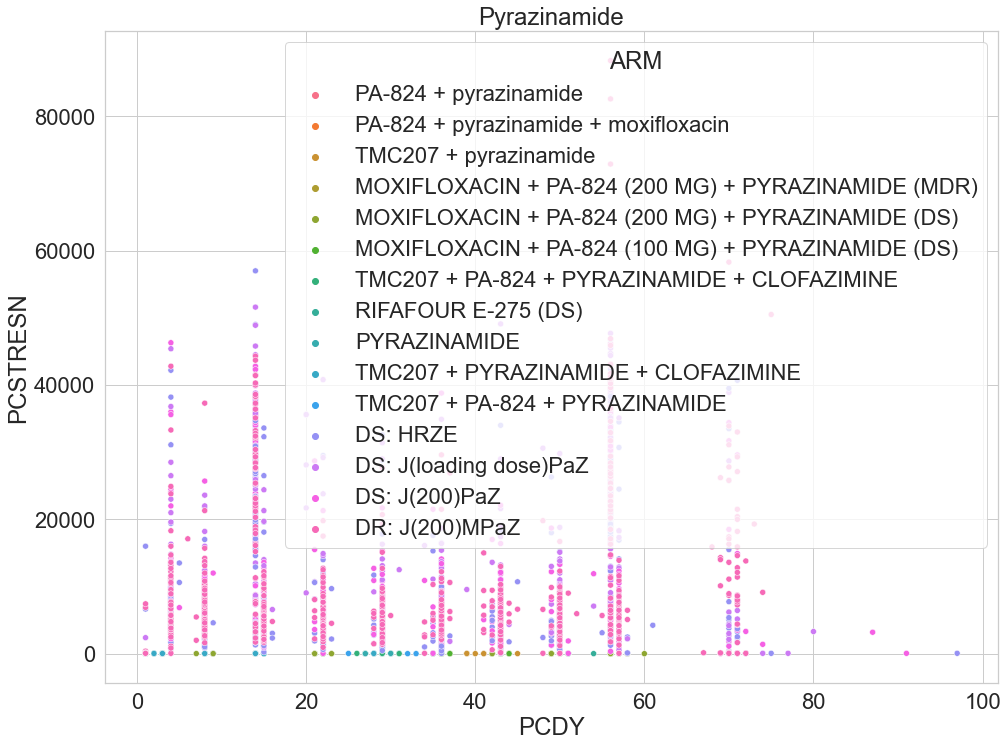

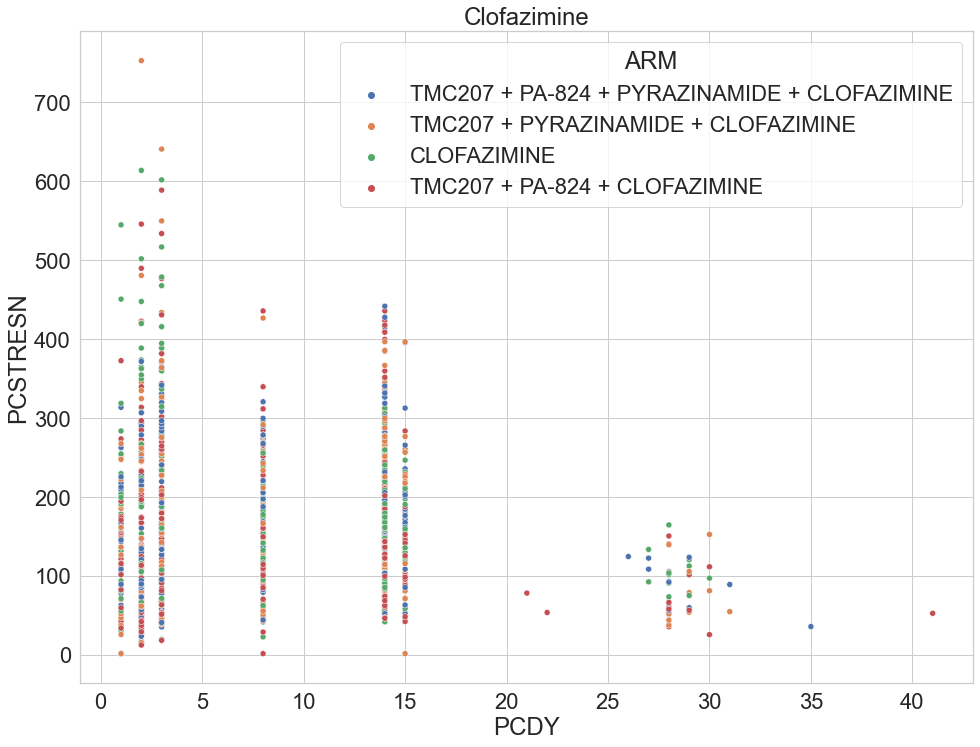

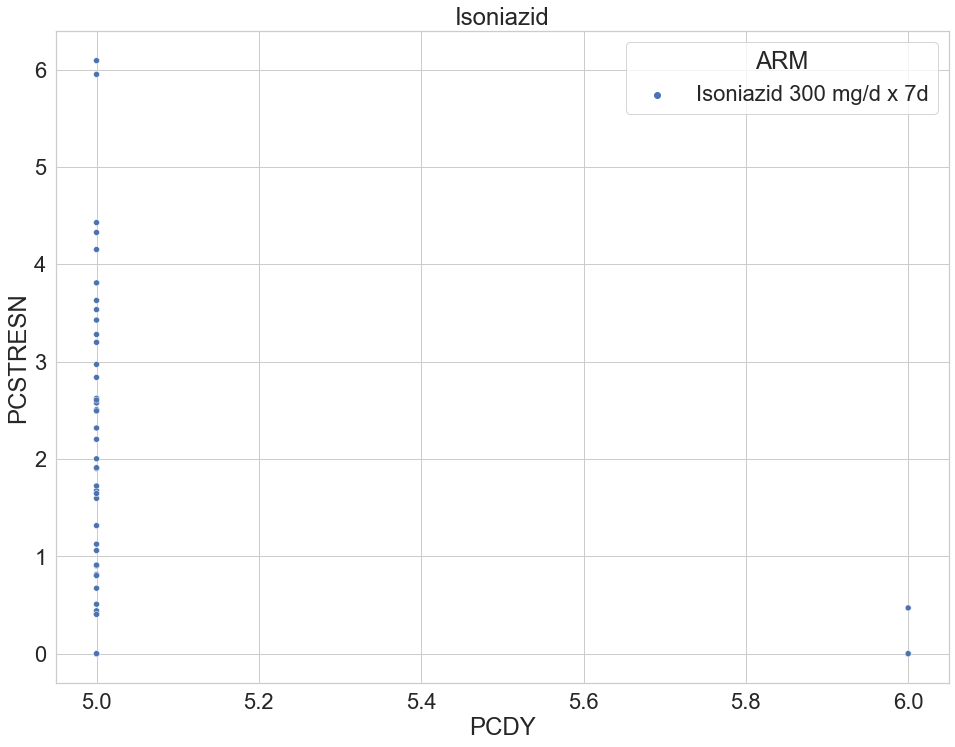

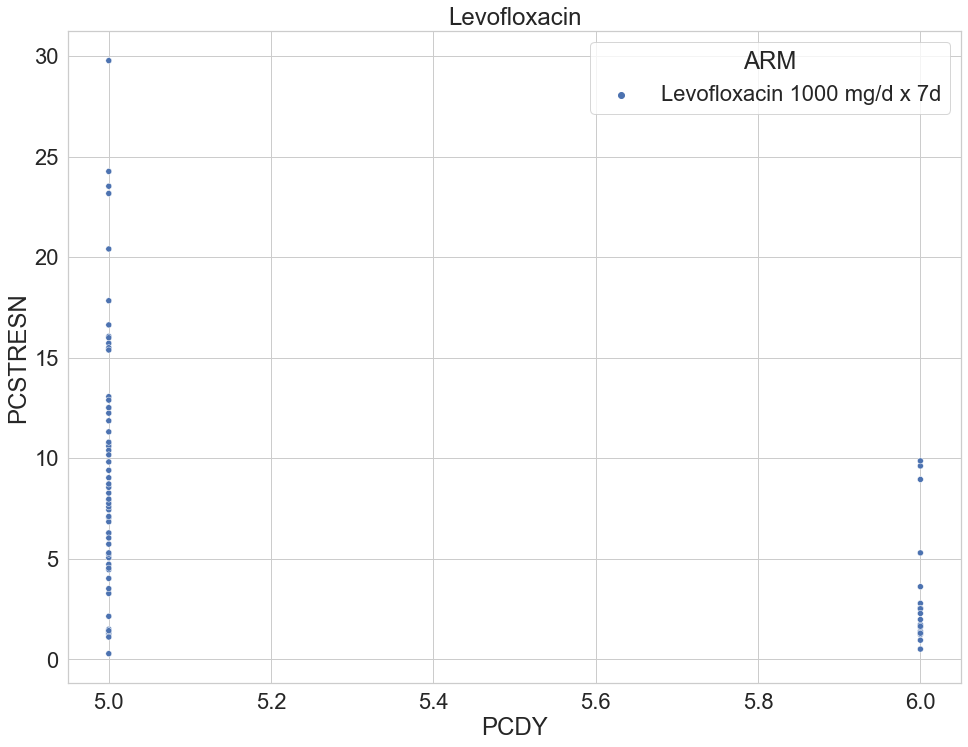

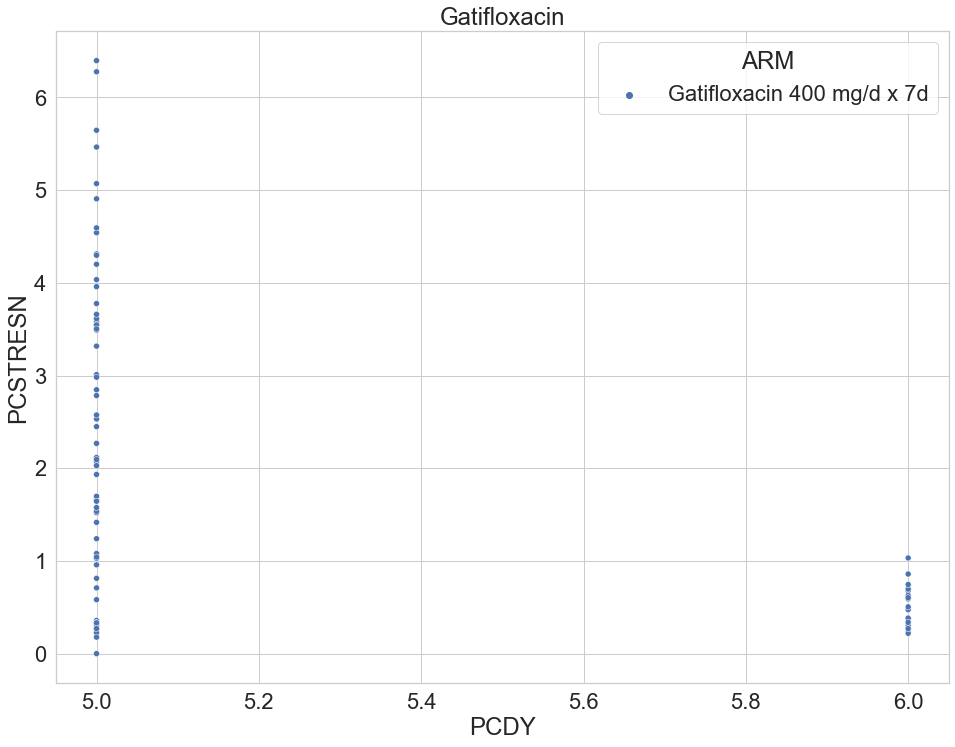

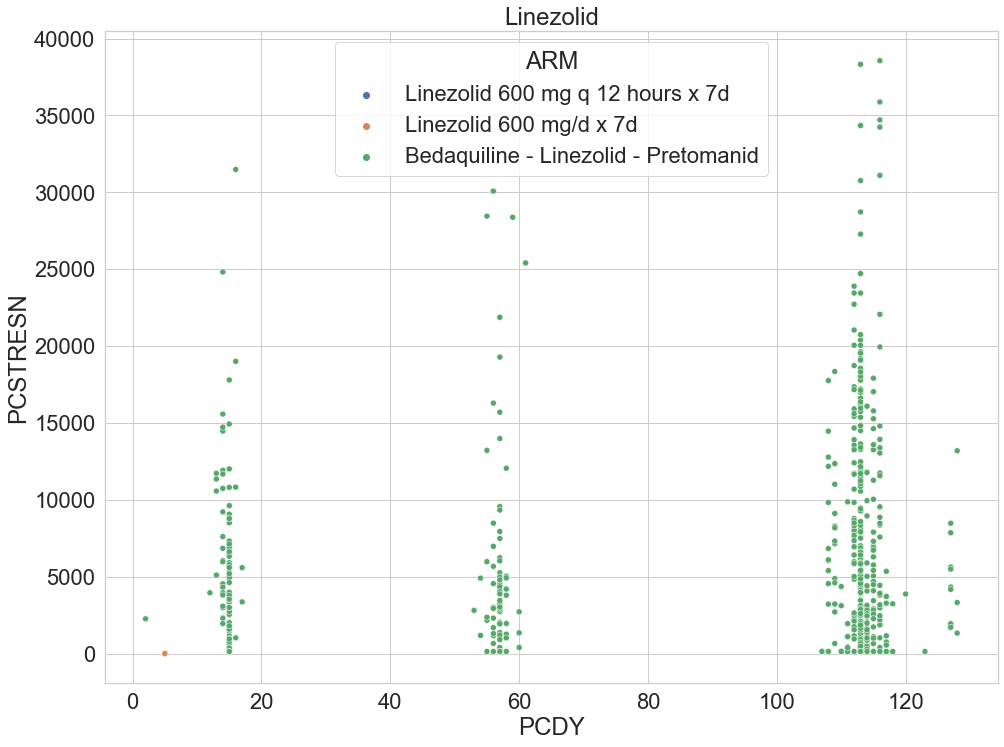

In [11]:
mb_oc=pd.read_csv('C-Path_data/preprocessing/mb_outcome.csv',low_memory=False)
pc['CURED']=np.nan
pc['TIME_TO_NEGATIVITY']=np.nan
pc_ids=pc['USUBJID'].unique()

for st in mb_oc['CURED'].unique():
    pats=mb_oc[mb_oc['CURED']==st]['USUBJID'].unique()
    pc.loc[pc['USUBJID'].isin(pats),'CURED']=mb_oc.loc[mb_oc['CURED']==st,'CURED']

for arm in mb_oc[mb_oc['USUBJID'].isin(pc_ids)]['ARM'].unique():
    pats=mb_oc[mb_oc['ARM']==arm]['USUBJID'].unique()
    pc.loc[pc['USUBJID'].isin(pats),'ARM']=mb_oc.loc[mb_oc['ARM']==arm,'ARM'].values[0]


for drug in pc['PCTEST'].unique():
    fig1,(ax1)=plt.subplots(figsize=(16,12))
    df=pc[pc['PCTEST']==drug]
    sns.scatterplot(data=df,x='PCDY',y='PCSTRESN',hue='ARM',ax=ax1)#,s=12)
    ax1.set_title(drug)
#print(pc['ARM'].value_counts(dropna=False))
#mb_oc[mb_oc['USUBJID'].isin(pc_ids)]

## Save preprocessed pharmacokinetic dataset as pk_pc_preprocessed.csv, use this for further analysis!!!

In [19]:
pc.to_csv(dir+'/data/ttp_pc_preprocessed.csv',index=None)

In [6]:
pc=pd.read_csv(dir+'/data/ttp_pc_preprocessed.csv',low_memory=False)



Create dictionaries with names of measured drugs data:
- pc_drugs_per_patient= pat_id:{[list of drugs measured per patient]}
- pc_drugs_per_studies= study_id:{[list of drugs measured per study]}

In [20]:
pk_drugs_per_patient= {}
pk_drugs_per_studies={}
ids=set(pc['USUBJID'].values)
ids=sorted(ids)

for id in ids:
    df=pc[pc['USUBJID']==id]
    df=df[~df['PCTEST'].str.contains('PK')]
    pk_drugs_per_patient[id]={}
    pk_drugs_per_patient[id]['measured_compounds']=list(set(df['PCTEST'].values))

for study in studies:
    df=pc[pc['STUDYID']==study]
    print(len(df['USUBJID'].unique()))
    df=df[~df['PCTEST'].str.contains('PK')]
    pk_drugs_per_studies[study]=list(set(df['PCTEST'].values))
    #pc_drugs_per_studies['No.of patients']=len(df['USUBJID'].unique())
for st in pk_drugs_per_studies:
    print (st,pk_drugs_per_studies[st])

pk_all_drugs=sorted({x for v in pk_drugs_per_studies.values() for x in v})

import pickle
f = open(dir+'/data/ttp_drugs_per_studies.pkl',"wb")
pickle.dump(pk_drugs_per_studies,f)
f.close()
f = open(dir+'/data/ttp_drugs_per_patient.pkl',"wb")
pickle.dump(pk_drugs_per_patient,f)
f.close()
f = open(dir+'/data/ttp_all_drugs.pkl',"wb")
pickle.dump(pk_all_drugs,f)
f.close()

58
86
69
61
95
61
58
222
110
TB-1031 ['Isoniazid', 'Linezolid', 'Levofloxacin', 'Gatifloxacin', 'Moxifloxacin']
TB-1014 ['Bedaquiline', 'N-Monodesmethyl Bedaquiline', 'Pretomanid', 'Clofazimine', 'Pyrazinamide']
TB-1008 ['Bedaquiline', 'N-Monodesmethyl Bedaquiline', 'Pretomanid', 'Moxifloxacin', 'Pyrazinamide']
TB-1007 ['Pretomanid']
TB-1018 ['Pretomanid', 'Bedaquiline', 'N-Monodesmethyl Bedaquiline', 'Linezolid']
TB-1003 ['Pretomanid']
TB-1005 ['Bedaquiline', 'N-Monodesmethyl Bedaquiline']
TB-1015 ['Bedaquiline', 'N-Monodesmethyl Bedaquiline', 'Pretomanid', 'Moxifloxacin', 'Pyrazinamide']
TB-1011 ['Pretomanid', 'Moxifloxacin', 'Pyrazinamide']





Visualize concentration-time curves of patients per study per drug

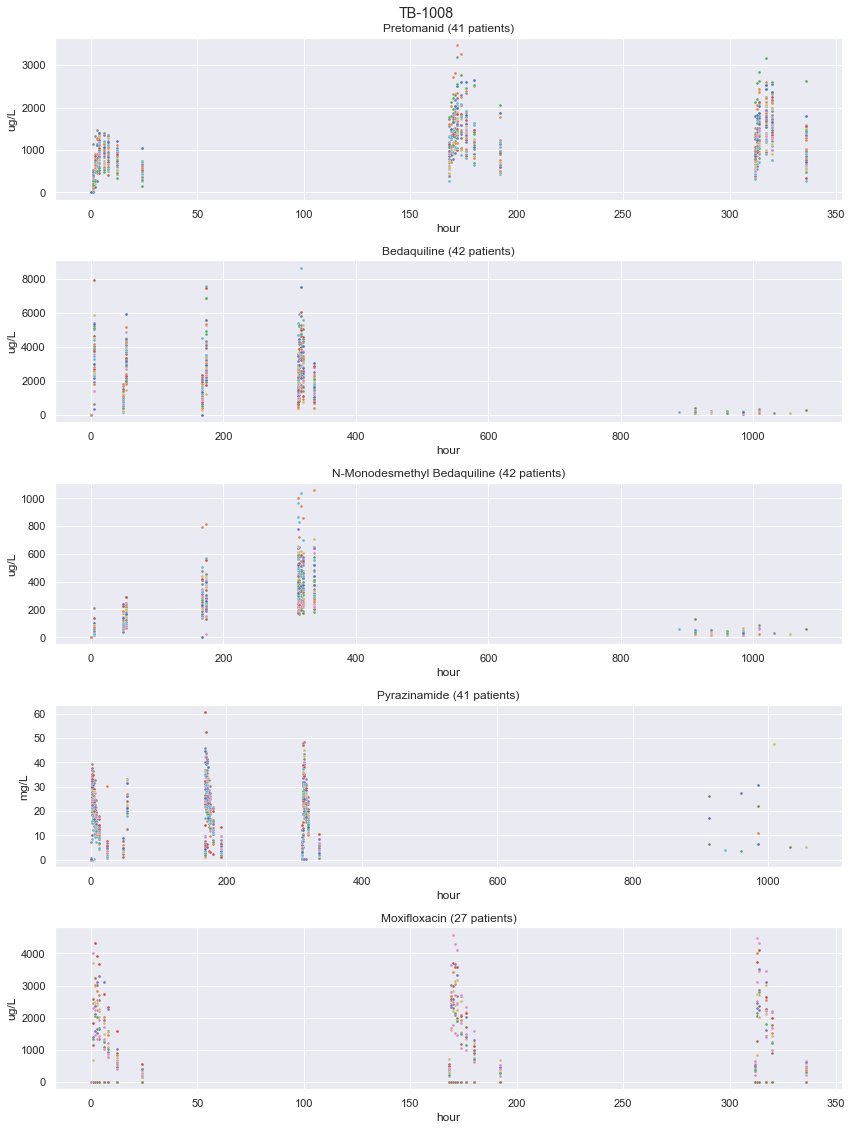

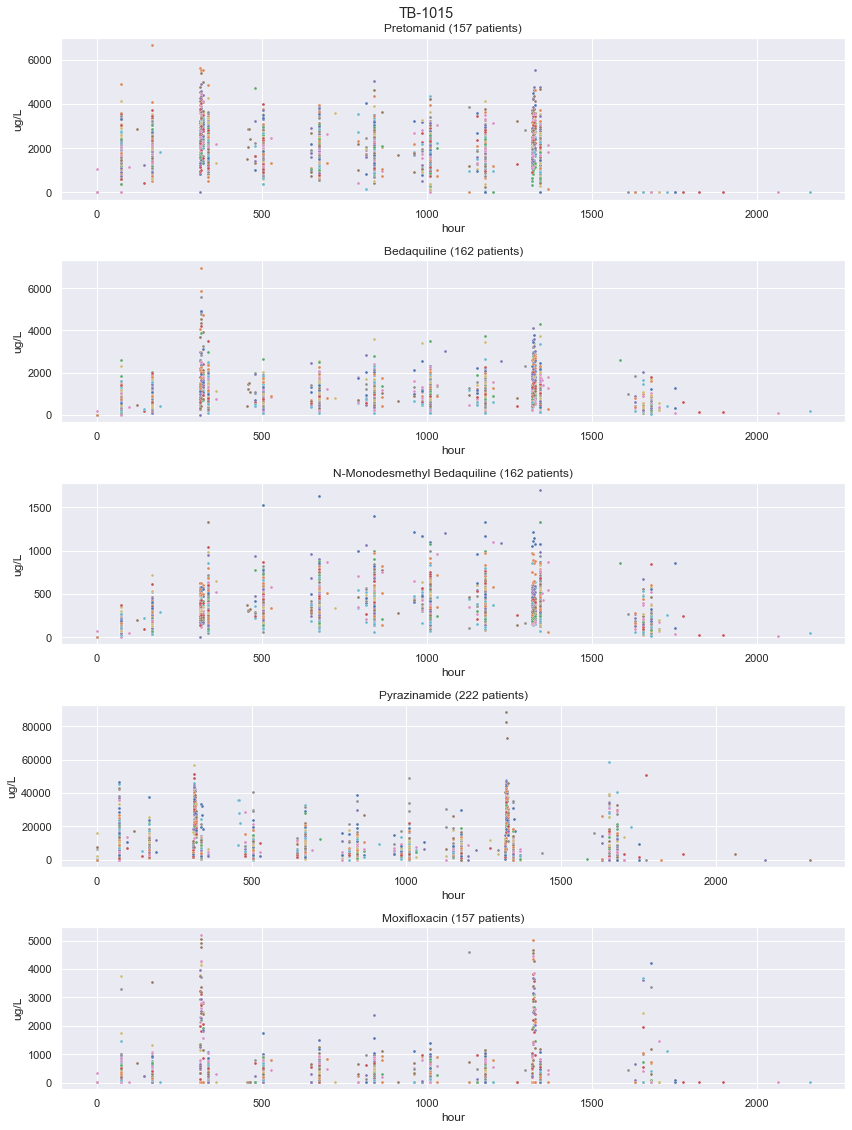

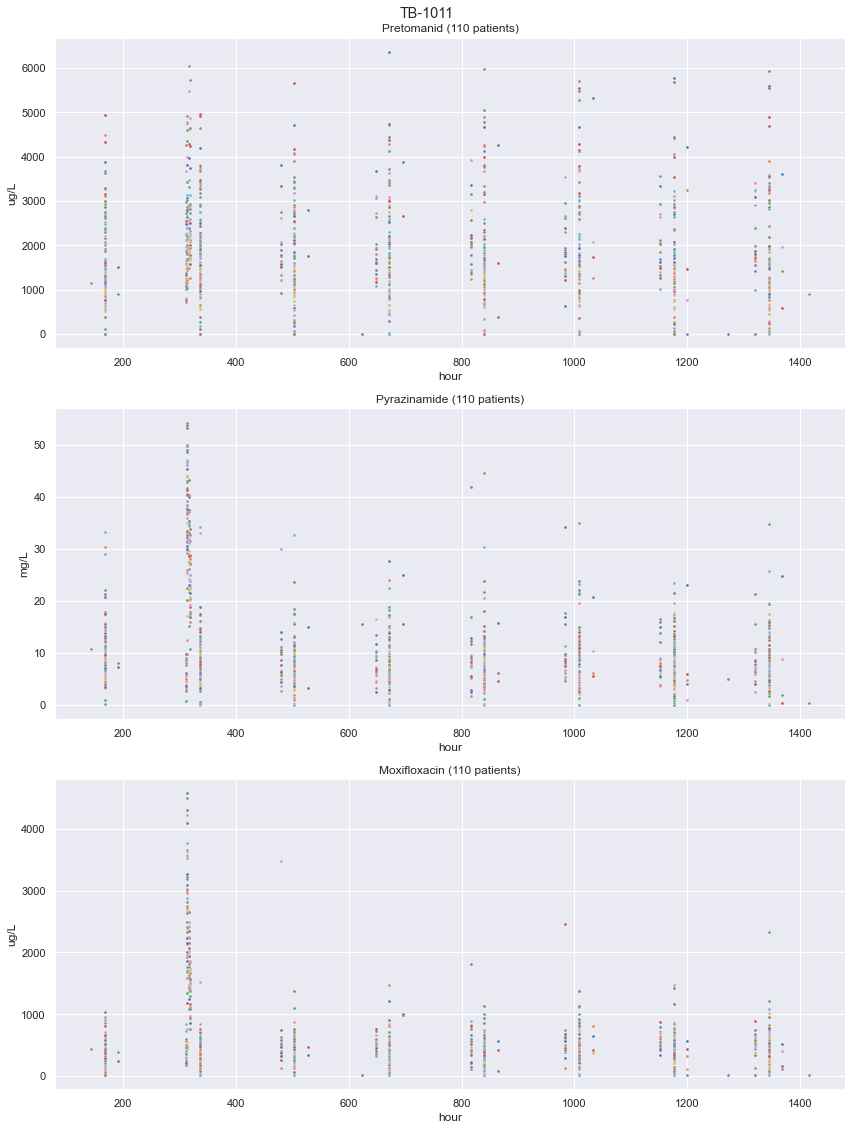

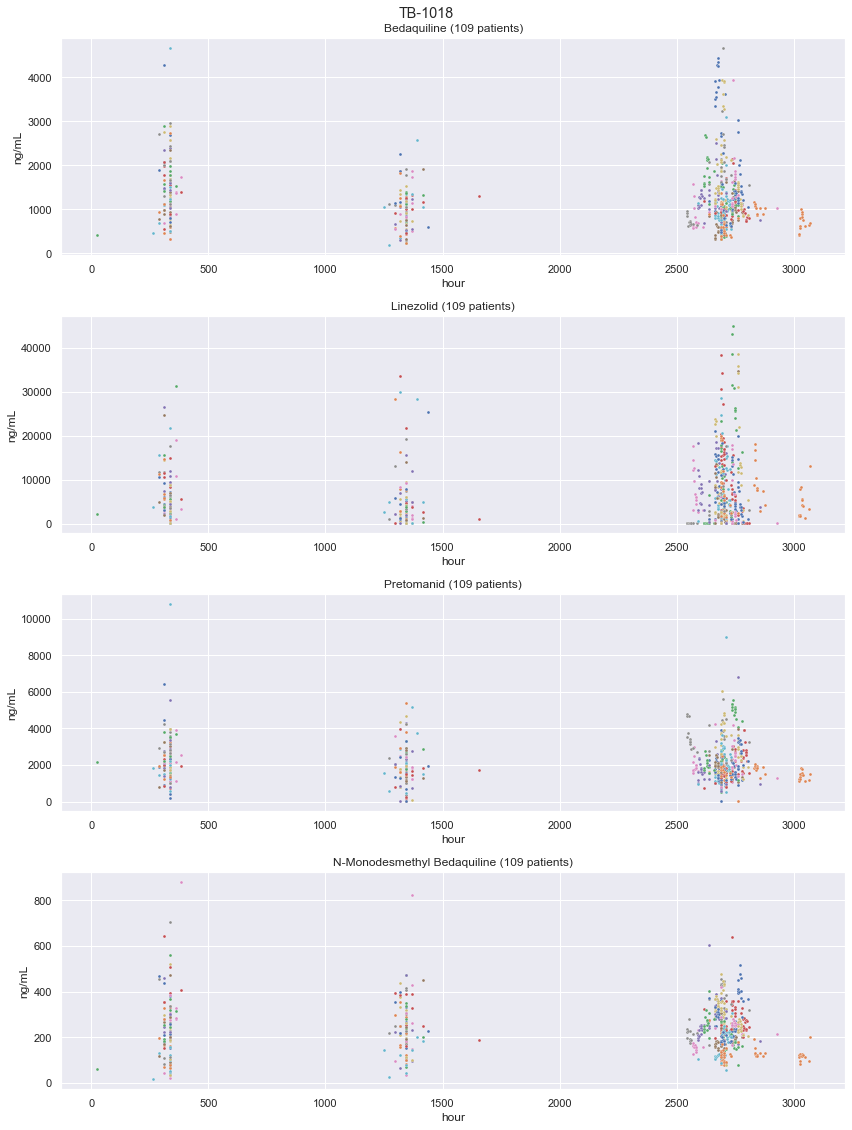

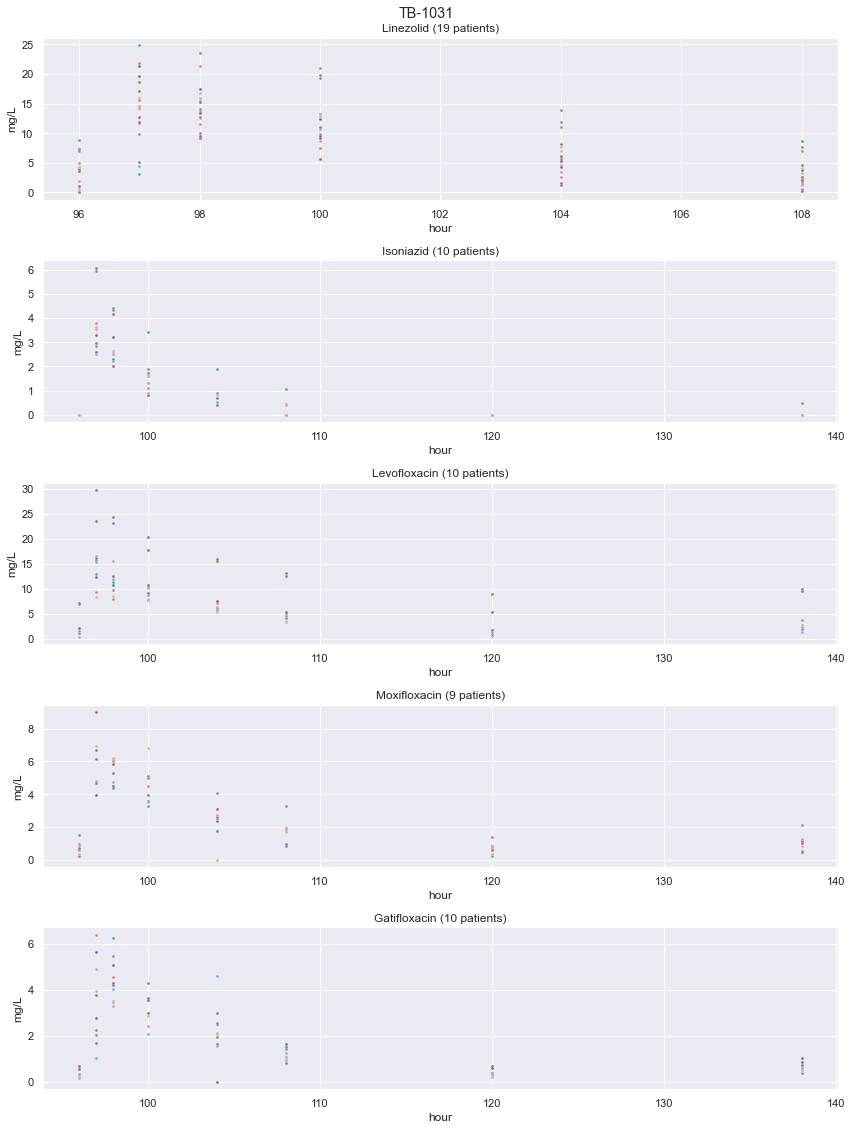

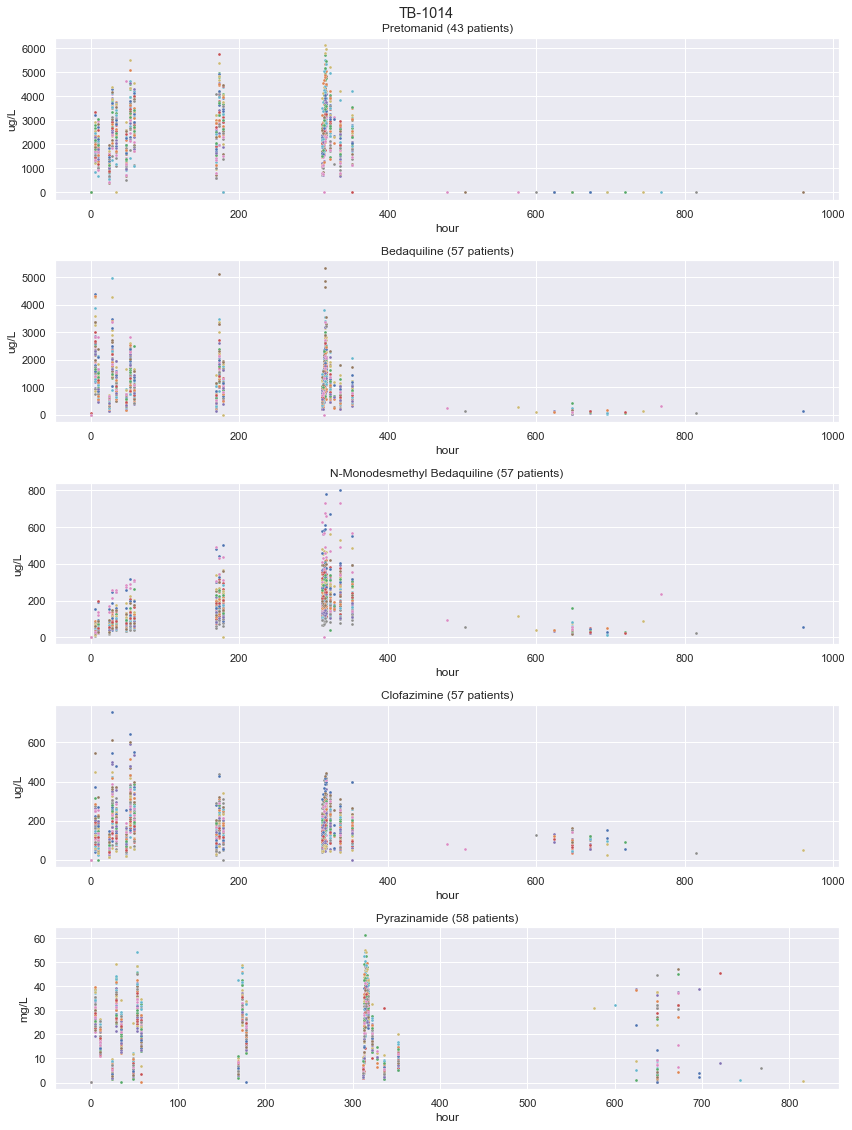

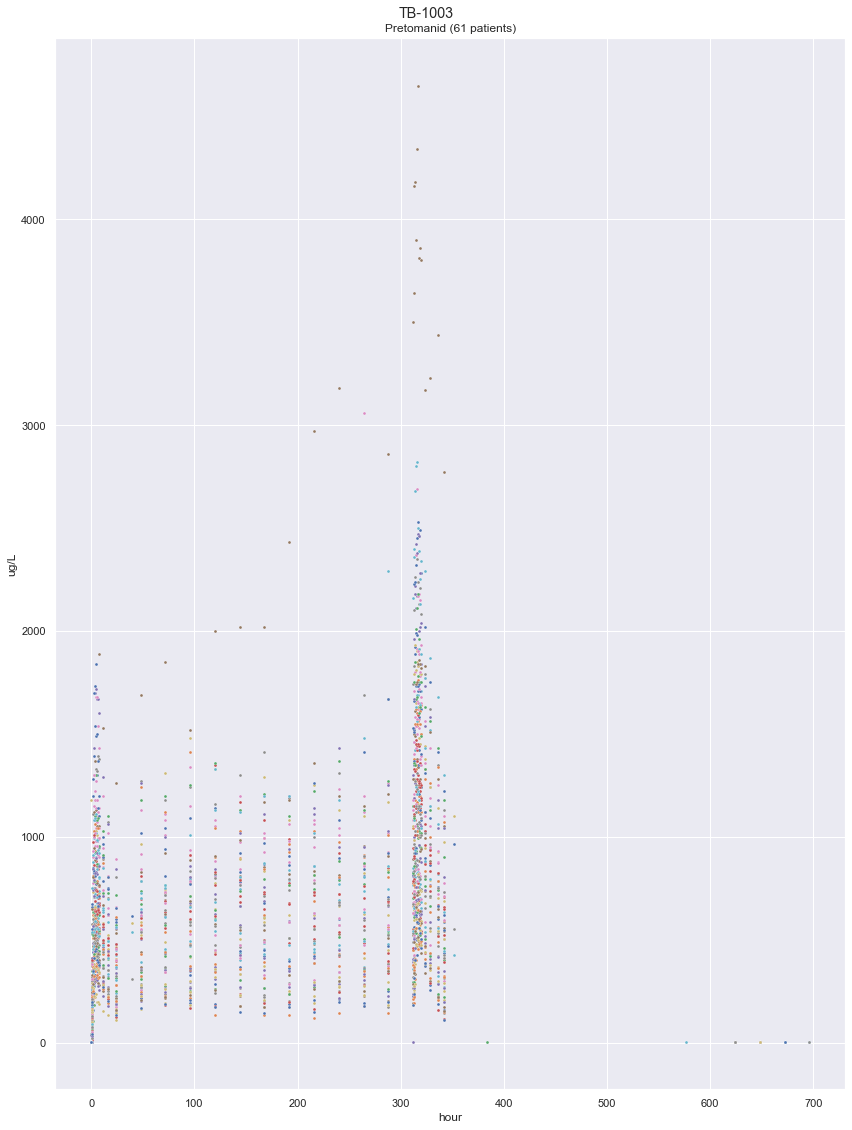

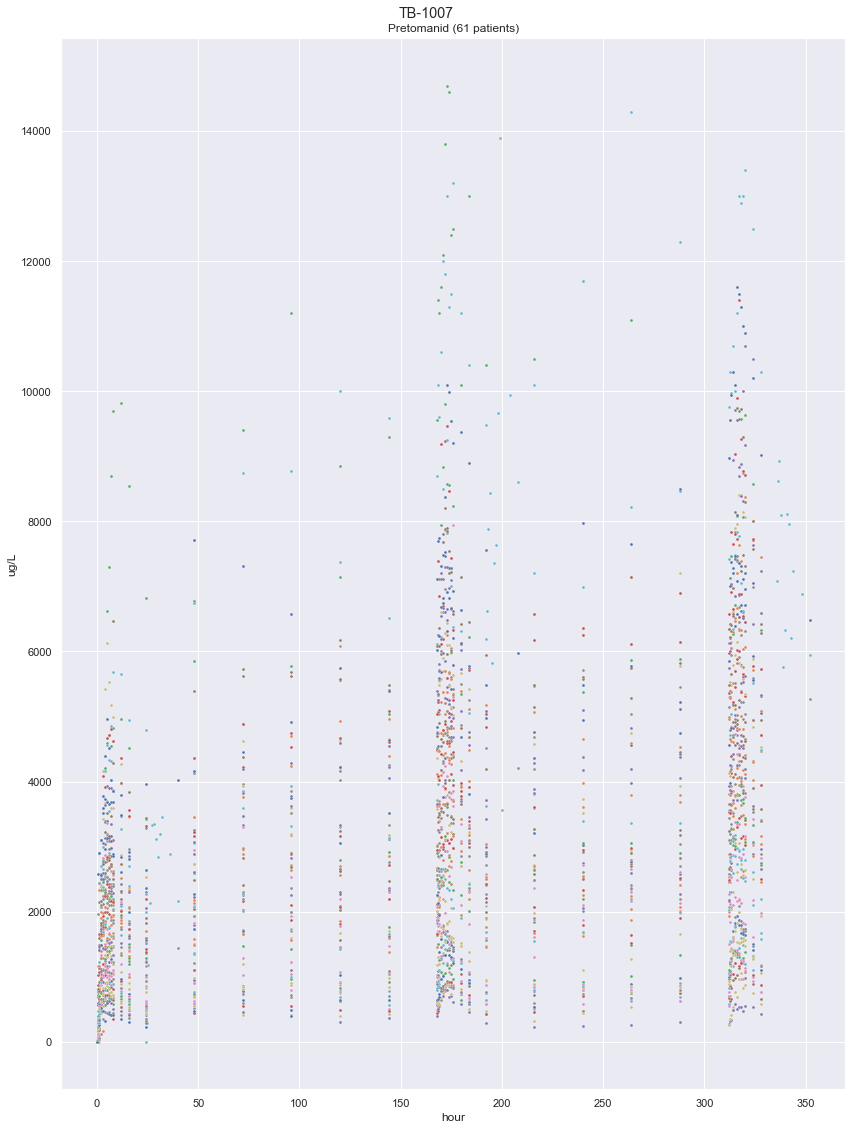

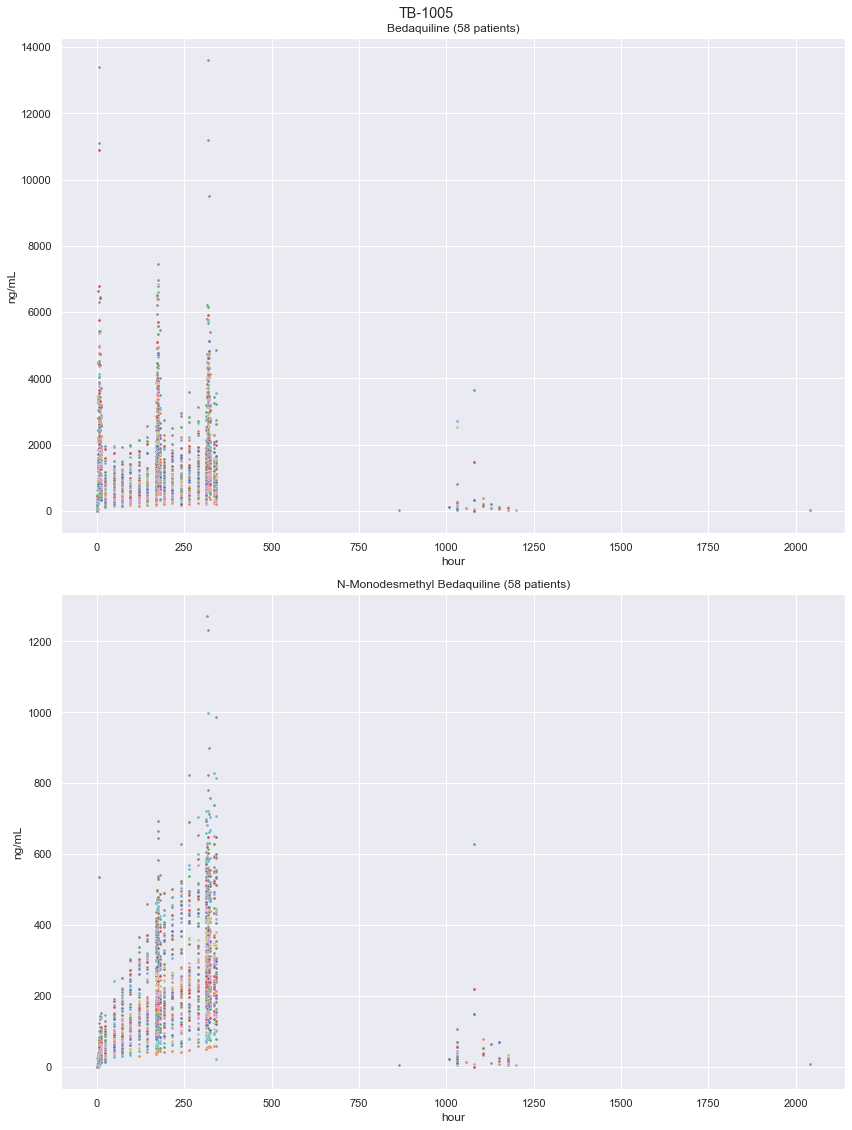

In [10]:
sns.set()
for study in list(studies)[:]:
    fig,ax=plt.subplots(len(pk_drugs_per_studies[study]),1,figsize=(12,16))
    fig.suptitle(study)
    df=pc[pc['STUDYID']==study]
    drug_df_list=df.groupby(by='PCTEST')
    pat_df_list=df.groupby(by='USUBJID')
    #print(pat_df_list.columns)
    for pat in pat_df_list:
        pat_df=pat[1]
        for dr_count,drug in enumerate(pk_drugs_per_studies[study]):
            dr_df=pat_df[pat_df['PCTEST']==drug]
            drug_df=drug_df_list.get_group(drug)
            pat_num=len(drug_df['USUBJID'].unique())
            if len(dr_df)>0:
                if len(pk_drugs_per_studies[study])>1:
                    sns.scatterplot(data=dr_df, x='hour', y='PCSTRESN',ax=ax[dr_count],s=9)
                    ax[dr_count].set_title(drug+' ('+str(pat_num)+' patients)')
                    ax[dr_count].set_ylabel(dr_df['PCSTRESU'].values[0])
                if len(pk_drugs_per_studies[study])<=1:
                    sns.scatterplot(data=dr_df, x='hour', y='PCSTRESN',ax=ax,s=9)
                    ax.set_title(drug+' ('+str(pat_num)+' patients)')
                    ax.set_ylabel(dr_df['PCSTRESU'].values[0])
        plt.tight_layout()
        #fig.savefig(dir+'/figs/'+study+'.png',dpi=150)


Create dict of dataframes of time-concentration measurements for clustering/plotting (heatmap or clustermap)
- Format of concentration dataframe: rows: hour of cc. measurement, columns: pat_id, elements of df: concentration values of drugs
- Format of dict: {study_id: {drug_in_study: cc_df}}

In [128]:
heatmap_df_dict={}
for study in list(studies)[:]:
    df=pc[pc['STUDYID']==study]
    heatmap_df_dict[study]={}
    heatmap_df_list=[]
    for dr_count,drug in enumerate(pk_drugs_per_studies[study]):
        dr_df=df[df['PCTEST']==drug]
        if len(dr_df)>0:
            heatmap_df=pd.DataFrame()
            pat_df_list=dr_df.groupby(by='USUBJID')
            for pat in pat_df_list:
                pat_id,pat_df,=pat[0],pat[1]
                cc_df=pat_df.loc[:,['PCSTRESN','hour']].sort_values(by='hour')
                cc_df=cc_df.rename(columns={'PCSTRESN':pat_id})
                cc_df.set_index(keys='hour',inplace=True)
                #if two measurements were measured in the same hour, keep the first
                cc_df=cc_df.loc[~cc_df.index.duplicated(keep='first')]
                #print(cc_df)
                heatmap_df=pd.concat([heatmap_df, cc_df], axis=1, join="outer")
            heatmap_df_dict[study][drug]=heatmap_df
            #print(heatmap_df)

heatmap_df_dict

{'TB-1011': {'Moxifloxacin':         TB-1011/1015  TB-1011/1021  TB-1011/1022  TB-1011/1028  TB-1011/1030  \
  hour                                                                           
  144.0            NaN           NaN           NaN           NaN           NaN   
  168.0          163.0         382.0         361.0         365.0         369.0   
  192.0            NaN           NaN           NaN           NaN           NaN   
  312.0          178.0         367.0         353.0         447.0         469.0   
  313.0         3270.0        1680.0        1930.0        1180.0        3530.0   
  314.0         3010.0        2140.0        2340.0        4100.0        3230.0   
  317.0         1700.0        1480.0        1600.0        2350.0        2150.0   
  320.0         1110.0        1110.0        1300.0        1670.0        1740.0   
  336.0          162.0         361.0         317.0         444.0         522.0   
  480.0            NaN           NaN           NaN           NaN       

KeyboardInterrupt: 

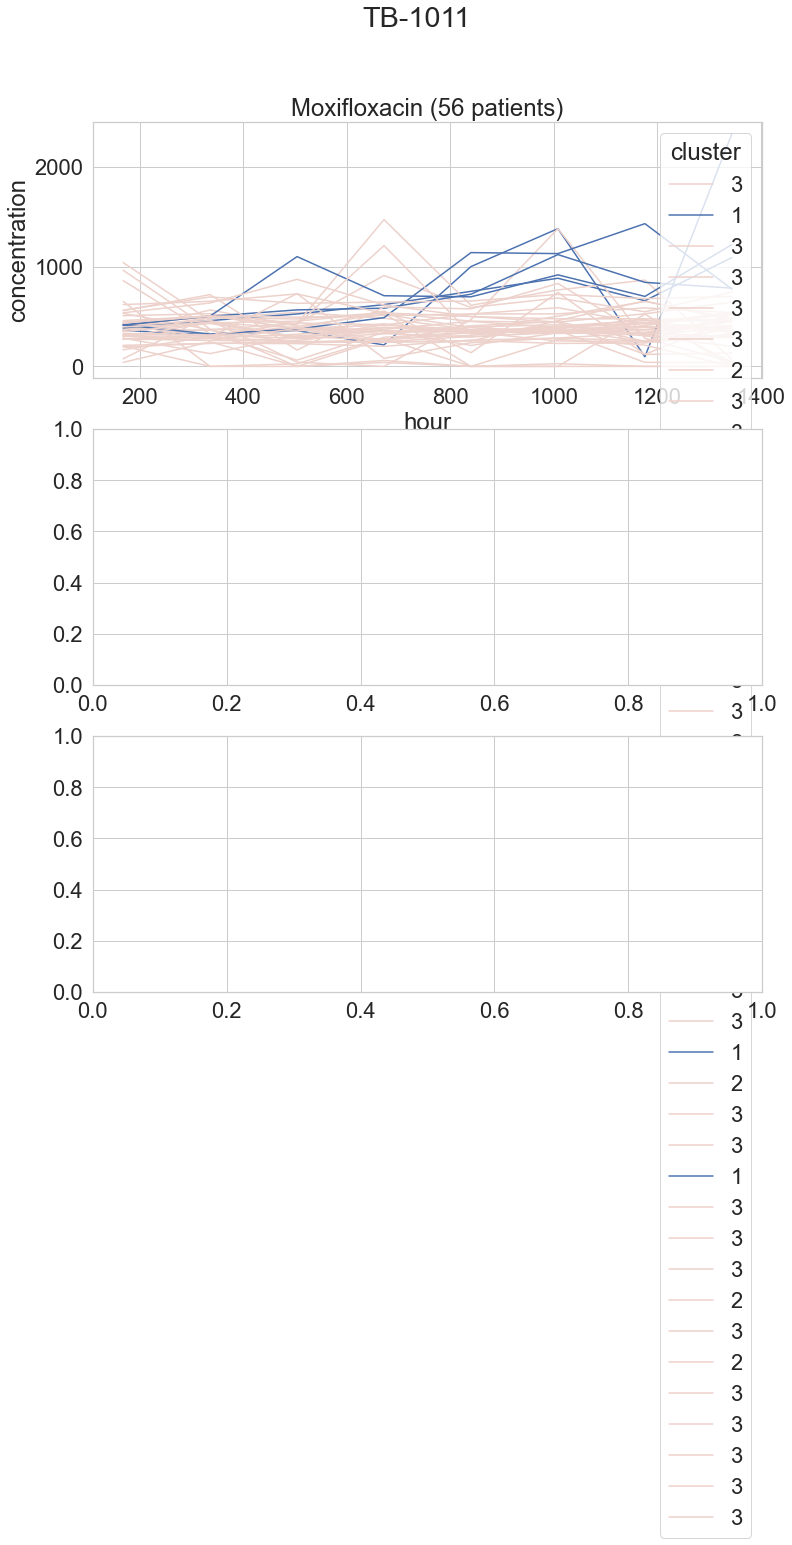

In [177]:
#sns.set()
n_fig=0
for study in [*heatmap_df_dict]:
    fig,ax=plt.subplots(len(pc_drugs_per_studies[study]),1,figsize=(12,16))
    fig.suptitle(study)
    drugs=[*heatmap_df_dict[study]]
    for n,drug in enumerate(drugs):
        cc_df=heatmap_df_dict[study][drug]
        #maximiaze retained measurement points by dropping NaN values in an optimal way,
        cc_df=drop_na(cc_df)
        #drop columns with only 0 values in them (TB-1008 & TB-1015 Moxifloxacin)
        cc_df=cc_df.loc[:, (cc_df != 0).any(axis=0)]
        if len(cc_df)>0:
            #cmap=sns.clustermap(cc_df,metric='euclidean',method='ward',z_score=None,row_cluster=False)
            #cmap.fig.set_size_inches(12, 16)
            #cmap.ax_heatmap.set_title(study+' '+drug+' ('+str(len(cc_df.columns))+' patients)')

            # retrieve clusters using fcluster
            clusters = get_clusters(cc_df,clustermap=False)
            cc_df.loc['cluster']=clusters
            #print(cc_df)

            cc_df=cc_df.T
            plot_df=pd.DataFrame()
            for pat_id in cc_df.iloc[0:-1].index:
                df=cc_df.loc[pat_id,:]
                df=df.reset_index()
                df=df.rename(columns={pat_id:'concentration'})
                df['cluster']=int(df.iloc[-1,1])
                df=df[:-1]
                #print(df)
                plot_df=plot_df.append(df,sort=False)
            #plot_df.reset_index(drop=True,inplace=True)

                if len(drugs)>1:
                    g=sns.lineplot(data=df,x='hour',y='concentration',ax=ax[n],hue='cluster')
                    g.set_title(drug+' ('+str(len(cc_df.index))+' patients)')
                    #leg=ax[n].get_legend()
                    #legend=[str(x)+': '+str(np.count_nonzero(clusters==x))+' patients' for x in list(set(clusters))]
                    #leg.set_title("Clusters")
                    #for t, l in zip(leg.texts,legend):
                        #t.set_text(l)
                    #ax[n].legend(g,legend,title='Clusters')
                else:
                    g=sns.lineplot(data=df,x='hour',y='concentration',ax=ax,hue='cluster')
                    g.set_title(drug+' ('+str(len(cc_df.index))+' patients)')
                    #h, l = g.get_legend_handles_labels()
                    #leg=ax.get_legend()
                    #legend=[str(x)+': '+str(np.count_nonzero(clusters==x))+' patients' for x in list(set(clusters))]
                    #leg.set_title("Clusters")
                    #for t, l in zip(leg.texts,legend):
                        #t.set_text(l)

                    #legend=[str(x)+': '+str(np.count_nonzero(clusters==x))+' patients' for x in list(set(clusters))]
                    #ax.legend(g,legend,title='Clusters')
            #fig.savefig(dir+'/figs/heatmap_'+study+'_'+drug+'.png',dpi=150)

plt.tight_layout()


Define function for optimal NaN dropping

In [14]:
def drop_na(cc_df,plot=None):
    # choose optimal threshold (range:0-1) for dropping NaN values from concentration dfs in order to keep maximal number of measured timepoints
    # no. of points between 0-1
    n_points=20
    ran1=np.linspace(0, 1.0, n_points)
    ran2=np.linspace(0, 1.0, n_points)
    ran_arr1=np.outer(ran1, np.ones(n_points))
    ran_arr2=np.outer(ran2, np.ones(n_points))

    #calculate dropping NaN values with different thresholds
    outcome=[]
    outcomec=[]
    for r1 in ran1:
        # first drop rows with NaNs
        df1=cc_df.dropna(axis=0,thresh=round(len(cc_df.columns)*r1))
        for r2 in ran2:
            #drop whole columns predominantly with NaNs
            df2=df1.dropna(axis=1,thresh=round(len(df1)*r2))
            #drop any missing rows with NaN
            df3=df2.dropna(axis=0,how='any')
            #outcome: n_rows*n_columns of concentration df-> maximized value
            oc=df3.shape[0]*df3.shape[1]
            outcome.append(oc)
    outcome=np.array(outcome)
    outcome=outcome.reshape(ran_arr1.shape)
    #Get indices of where outcome is maximal, than indentify the proper thresholds
    indices = np.where(outcome == outcome.max())
    #(more threshold possible-> get the last one from the list
    r1=ran_arr1[indices][-1]
    r2=ran_arr2.T[indices][-1]

    #if plot=True, plot 3d plots of outcome space
    if plot is not None:
        from mpl_toolkits.mplot3d import Axes3D
        fig = plt.figure(figsize=(14,14))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(ran_arr1, (ran_arr2).T, outcome,cmap="plasma")
        ax.set_title(study+' '+drug)
        ax.set_xlabel('r1')
        ax.set_ylabel('r2')
        ax.set_zlabel('df n_rows * n_columns')

    #drop NaNs from cc df with optimal thresolds
    cc_df=cc_df.dropna(axis=0,thresh=round(len(cc_df.columns)*r1))
    cc_df=cc_df.dropna(axis=1,thresh=round(len(cc_df)*r2))
    cc_df=cc_df.dropna(axis=0,how='any')
    return cc_df

In [172]:
def get_clusters(cc_df,dist_metric='euclidean',linkage_method='ward',fcluster_method='distance',clustermap=False):
    from scipy.spatial.distance import pdist, squareform
    from scipy.cluster.hierarchy import cophenet,dendrogram, linkage

    # df format: row names: pat_ids, columns: measurement timepoints
    #in order to cluster measured timepoints of patient together, transpose df
    d = sch.distance.pdist(cc_df.T)
    d = sch.distance.pdist(cc_df.T,metric=dist_metric)
    L = sch.linkage(d, method=linkage_method)
    clusters = sch.fcluster(L, 0.8*d.max(), fcluster_method)
    if clustermap is True:
        cmap=sns.clustermap(cc_df,metric='euclidean',method='ward',z_score=None,row_cluster=False)
        cmap.fig.set_size_inches(12, 16)
        cmap.ax_heatmap.set_title(study+' '+drug+' ('+str(len(cc_df.columns))+' patients) '+ str(len(clusters))+' clusters')
        #cmap.savefig(dir+'/figs/heatmap_'+study+'_'+drug+'.png',dpi=150)

    #clust_dict: dict of {pat_id:cluster}
    clust_dict=dict(zip(cc_df.columns,clusters))
    return clust_dict
